# A fixed-boundary CHEASE equilibrium from 0D descriptors

> What does it take to turn $R_0, a, \kappa, \delta, B_T, I_p$ into a force-balanced equilibrium, and what does the result then *not* get to choose?

A fixed-boundary Grad–Shafranov solution is fixed by three things:
1. the **boundary**;
2. the two **source functions** $p'(\psi)$ and $FF'(\psi)$;
3. one **normalization**.

`vaft.code.chease_synthesis` asks for exactly those and nothing more:

- **Boundary:** a Miller LCFS from $R_0, a, \kappa, \delta, Z_0$.
- **Sources:** generalized-parabolic *shapes* of $p'(\psi_N)$ and $FF'(\psi_N)$, plus `pressure_fraction`, the share of the on-axis source $\mu_0R_0^2p' + FF'$ that the pressure carries.
  Either shape may instead be a #1045 barrier profile (edge pedestal, ITB), whose analytic $\psi_N$ derivative is the shape (Section 5).
  With a barrier profile for *either* source, `pressure_fraction` becomes the pressure's share of the $\psi_N$-*integrated* source, even for a source that stays parabolic (Section 5).
- **Normalization:** whichever one CHEASE can impose. That is the plasma current (`NCSCAL = 2`) *or* $q$ at $\psi_N = 0.95$ (`NCSCAL = 1`).

Everything else is an *achieved output*, measured on the solved equilibrium and reported beside the request: $q_0$, the other of $I_p$ and $q_{95}$, $\beta_t$, $\beta_N$, $l_i$ and the Shafranov shift.

**Requirements.** Section 1 needs only VAFT. The CHEASE sections need a CHEASE executable (`CHEASE`, `CHEASEHOME` or `CHEASE_EXEC_DIR`), and are skipped with a message when there is none.

In [ ]:
import dataclasses
import tempfile
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from vaft.code.chease import CHEASEConfig, find_chease_executable
from vaft.code.chease_synthesis import (
    ZeroDimensionalEquilibriumSpec, construct_boundary, synthesize_equilibrium_from_0d,
)
from vaft.data.eqdsk import read_geqdsk
from vaft.process.equilibrium import as_equilibrium, contour_shape_parameters
from vaft.formula.equilibrium import generalized_parabolic_profile
from vaft.plot.analytic import plot_solovev_equilibrium

HAVE_CHEASE = find_chease_executable() is not None
WORK = Path(tempfile.mkdtemp(prefix="vaft-0d-chease-"))
print("CHEASE available:", HAVE_CHEASE)

vest = ZeroDimensionalEquilibriumSpec(
    major_radius=0.40, minor_radius=0.235, elongation=1.7, triangularity=0.35,
    toroidal_field=0.10, plasma_current=100e3,
    pressure_fraction=0.5, pressure_alpha=1.0, pressure_beta=2.0, current_alpha=1.0, current_beta=1.0,
)

CHEASE available: True


## 1. The request: boundary and source shapes

The boundary is built first, and its shape is measured back before anything
is solved. The source shapes are shown in $\psi_N$; their common amplitude is
not an input, because CHEASE sets it to meet the normalization.

requested kappa=1.7, delta=0.35;  constructed kappa=1.7000, delta_upper=0.3500, delta_lower=0.3500


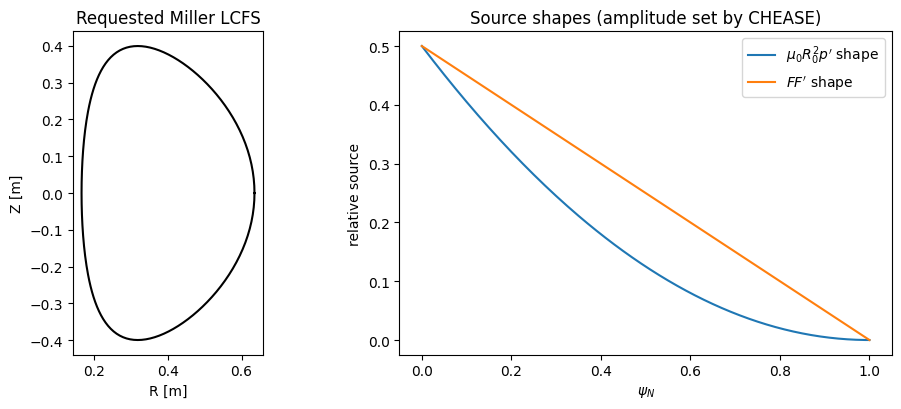

In [ ]:
boundary = construct_boundary(vest)
shape = contour_shape_parameters(boundary.r, boundary.z)
print(f"requested kappa={vest.elongation}, delta={vest.triangularity};  constructed kappa={shape['elongation']:.4f}, "
      f"delta_upper={shape['triangularity_upper']:.4f}, delta_lower={shape['triangularity_lower']:.4f}")
psi_n = np.linspace(0, 1, 201)
fig, (b_ax, s_ax) = plt.subplots(1, 2, figsize=(10, 4.2))
b_ax.plot(np.r_[boundary.r, boundary.r[0]], np.r_[boundary.z, boundary.z[0]], "k-")
b_ax.set_aspect("equal"); b_ax.set(xlabel="R [m]", ylabel="Z [m]", title="Requested Miller LCFS")
s_ax.plot(psi_n, vest.pressure_fraction*generalized_parabolic_profile(psi_n, alpha=vest.pressure_alpha, beta=vest.pressure_beta),
          label=r"$\mu_0R_0^2 p'$ shape")
s_ax.plot(psi_n, (1 - vest.pressure_fraction)*generalized_parabolic_profile(psi_n, alpha=vest.current_alpha, beta=vest.current_beta),
          label=r"$FF'$ shape")
s_ax.set(xlabel=r"$\psi_N$", ylabel="relative source", title="Source shapes (amplitude set by CHEASE)")
s_ax.legend(); fig.tight_layout(); plt.show()

## 2. Normalize to the plasma current

CHEASE solves with the requested $I_p$ (`NCSCAL = 2`). The table lists every
request next to what was achieved. $q_0$ and $q_{95}$ are outputs here, not
inputs.

With these sources, 100 kA at 0.1 T gives $q_0 \approx 0.4$ and $q_{95} \approx 2.3$.
Both are consequences of the assumptions, not targets. To aim for a given edge
safety factor, normalize to $q_{95}$ as in Section 3.

In [ ]:
def show(result):
    print(f"status: {result.status}" + (f" ({result.reason})" if result.reason else ""))
    for name, value in result.achieved.items():
        print(f"  {name:22s} {value: .5g}")
    print("  residuals:", {k: round(v, 4) for k, v in result.residuals.items()})

if HAVE_CHEASE:
    by_current = synthesize_equilibrium_from_0d(vest, config=CHEASEConfig(workdir=WORK / "ip"))
    show(by_current)
else:
    print("CHEASE not found: skipping the solves.")

status: success
  ip                      1e+05
  q0                      0.41914
  q95                     2.289
  bt0                     0.099999
  major_radius            0.4
  minor_radius            0.235
  elongation              1.6998
  geometric_center_z      0
  beta_t                  0.13152
  beta_n                  3.0906
  li_virial               1.2001
  shafranov_shift         0.044575
  magnetic_axis_r         0.44458
  magnetic_axis_z        -7.3913e-11
  volume                  0.69211
  beta_p                  0.34487
  triangularity_upper     0.3493
  triangularity_lower     0.3493
  residuals: {'plasma_current': 0.0, 'toroidal_field': -0.0, 'elongation': -0.0001, 'minor_radius': -0.0, 'major_radius': 0.0, 'triangularity_upper': -0.0007, 'triangularity_lower': -0.0007, 'vertical_position': 0.0, 'pressure_shape': 0.0, 'pprime_peak': -0.0, 'pprime_peak_location': 0.0}


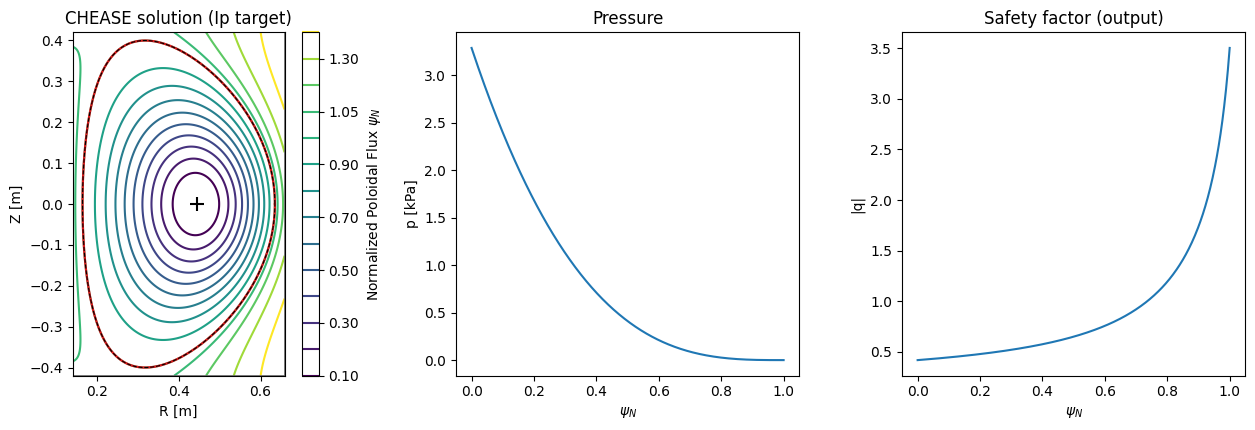

In [ ]:
if HAVE_CHEASE:
    solved = as_equilibrium(read_geqdsk(Path(by_current.chease.workdir) / "EQDSK_COCOS_02.OUT"))
    fig, axes = plt.subplots(1, 3, figsize=(13, 4.4))
    plot_solovev_equilibrium(solved, ax=axes[0], title="CHEASE solution (Ip target)")
    axes[0].plot(np.r_[boundary.r, boundary.r[0]], np.r_[boundary.z, boundary.z[0]], "k--", lw=0.8)
    x = (solved.psi_1d - solved.psi_axis) / (solved.psi_boundary - solved.psi_axis)
    axes[1].plot(x, solved.pressure / 1e3); axes[1].set(xlabel=r"$\psi_N$", ylabel="p [kPa]", title="Pressure")
    axes[2].plot(x, np.abs(solved.q)); axes[2].set(xlabel=r"$\psi_N$", ylabel="|q|", title="Safety factor (output)")
    fig.tight_layout(); plt.show()

## 3. Normalize to $q_{95}$ instead

With `NCSCAL = 1`, CHEASE matches $q(\psi_N = 0.95)$ and the plasma current
becomes the output. It is one scaling or the other; CHEASE cannot impose both
in the same solve.

The two normalizations rescale **one** solution: $p'$ and $FF'$ are multiplied
together, so the flux-surface geometry, $l_i$ and the Shafranov shift are
identical to Section 2. Only the amplitude changes: $I_p$ scales with it, and
$\beta_t$ with its square. Changing the shape of the equilibrium needs a
different source *shape*, as Section 4 shows.

In [ ]:
if HAVE_CHEASE:
    by_q = synthesize_equilibrium_from_0d(vest, target="q95", q95=6.0, config=CHEASEConfig(workdir=WORK / "q95"))
    show(by_q)

status: success
  ip                      38097
  q0                      0.79856
  q95                     6.0003
  bt0                     0.099999
  major_radius            0.4
  minor_radius            0.235
  elongation              1.6998
  geometric_center_z      0
  beta_t                  0.019088
  beta_n                  1.1774
  li_virial               1.2001
  shafranov_shift         0.044575
  magnetic_axis_r         0.44458
  magnetic_axis_z        -7.3913e-11
  volume                  0.69211
  beta_p                  0.34487
  triangularity_upper     0.3493
  triangularity_lower     0.3493
  residuals: {'q95': 0.0, 'toroidal_field': -0.0, 'elongation': -0.0001, 'minor_radius': -0.0, 'major_radius': 0.0, 'triangularity_upper': -0.0007, 'triangularity_lower': -0.0007, 'vertical_position': 0.0, 'pressure_shape': 0.0, 'pprime_peak': -0.0, 'pprime_peak_location': 0.0}


## 4. The same 0D description, different equilibria

Geometry, $B_T$ and $I_p$ do not determine an equilibrium. Changing only the
source assumptions -- the pressure share, or how peaked the current source is
-- gives a different $q_0$, $\beta_t$, $l_i$ and Shafranov shift, all with
the same boundary and current. That is why the source model is an explicit,
required input here, and not a hidden default.

(The default sources give $\beta_t \approx 13\,\%$ at 0.1 T. That is a
consequence of the assumed pressure share, not a realistic VEST baseline.)

In [ ]:
if HAVE_CHEASE:
    variants = {
        "baseline": vest,
        "pressure share 0.2": dataclasses.replace(vest, pressure_fraction=0.2),
        "pressure share 0.8": dataclasses.replace(vest, pressure_fraction=0.8),
        "peaked current": dataclasses.replace(vest, current_beta=3.0),
    }
    print(f"{'variant':20s} {'q0':>6s} {'q95':>6s} {'beta_t':>7s} {'li':>6s} {'shift [cm]':>10s} {'Ip [kA]':>8s}")
    for name, spec in variants.items():
        r = synthesize_equilibrium_from_0d(spec, config=CHEASEConfig(workdir=WORK / name.replace(" ", "_")))
        a = r.achieved
        print(f"{name:20s} {a['q0']:6.2f} {a['q95']:6.2f} {a['beta_t']:7.3f} {a['li_virial']:6.2f} "
              f"{100*a['shafranov_shift']:10.2f} {a['ip']/1e3:8.1f}  [{r.status}]")

variant                  q0    q95  beta_t     li shift [cm]  Ip [kA]


baseline               0.42   2.29   0.132   1.20       4.46    100.0  [success]


pressure share 0.2     0.62   2.31   0.040   1.01       2.94    100.0  [success]


pressure share 0.8     0.23   2.23   0.298   1.54       6.17    100.0  [success]


peaked current         0.19   2.04   0.332   2.08       6.28    100.0  [success]


## 5. H-mode and ITB pressure sources (#1166 scope B)

The generalized-parabolic kernel cannot make a pedestal or an internal
transport barrier. `pressure_profile` accepts a #1045 barrier profile instead:
an `AnalyticProfile` from `compose_analytic_profile`, or a whole
`AnalyticPlasmaState` preset, whose $p_\mathrm{tot}$ is then used. The $p'$
shape handed to CHEASE is the profile's analytic derivative
$-dp/d\psi_N$. Two things change with a profile source:

- Only the **shape** of $p(\psi_N)$ is imposed. Its absolute level in Pa and
  its separatrix value are dropped, because CHEASE rescales the amplitude to
  the normalization and a constant pressure does not enter the
  Grad–Shafranov equation.
- Both shapes are scaled to unit integral in $\psi_N$. `pressure_fraction` is
  then the pressure's share of the $\psi_N$-*integrated* source, since a
  profile's gradient can vanish on axis. This also applies to a source that stays
  parabolic: with only a `current_profile`, `pressure_fraction = 0.5` gives an
  *on-axis* pressure share of 0.67 with the default kernels. Compare cases
  through the achieved descriptors, not through `pressure_fraction`.

`current_profile` does the same for $FF'$ (Section 5.3).

> **A pedestal here is a source prescription, not a predicted pedestal.**
> A steep $p'$ on a fixed boundary is solved *consistently*. Its width, its
> height and its stability are still what was asked for: no EPED,
> peeling–ballooning limit or bootstrap current is involved. The same holds
> for the ITB.

All three cases below use the same boundary, $I_p$ and `pressure_fraction = 0.3`:

- **L-mode-like:** the `analytic_lmode_state` preset, a smooth core with no
  barrier.
- **H-mode:** the `analytic_hmode_state` preset, with its pedestal centred at
  $\psi_N = 0.93$ and full width 0.05.
- **ITB:** the `analytic_itb_state` preset, with its barrier at $\psi_N = 0.3$.

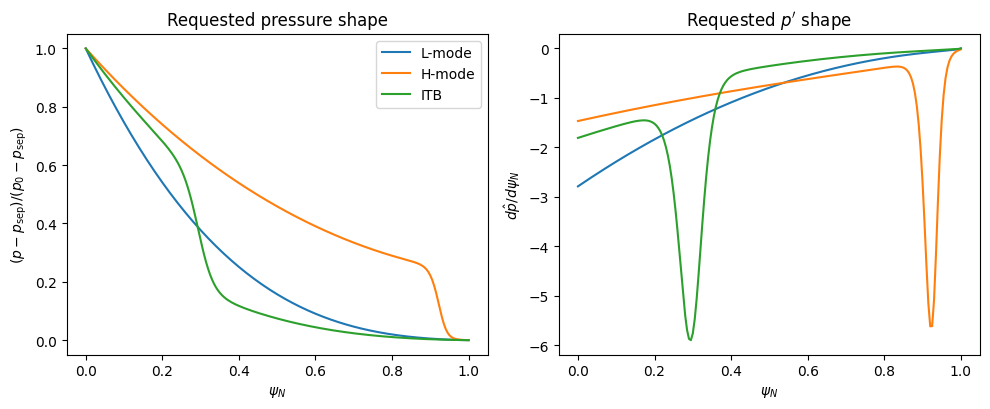

In [ ]:
from vaft.code.chease_synthesis import requested_pressure_shape
from vaft.process.profile import (
    analytic_hmode_state, analytic_itb_state, analytic_lmode_state, compose_analytic_profile,
)

regimes = {"L-mode": analytic_lmode_state(), "H-mode": analytic_hmode_state(), "ITB": analytic_itb_state()}
regime_specs = {name: dataclasses.replace(vest, pressure_profile=state, pressure_fraction=0.3)
                for name, state in regimes.items()}
# A pressure-only profile for the refusal example of Section 6.
hmode_p = compose_analytic_profile("p", unit="Pa", axis_value=1.0e3, separatrix_value=20.0,
                                   pedestal_top_value=450.0, pedestal_position=0.93, pedestal_width=0.05)
fig, (p_ax, d_ax) = plt.subplots(1, 2, figsize=(10, 4.2))
for name, spec in regime_specs.items():
    p_req, dp_req = requested_pressure_shape(spec, psi_n)
    p_ax.plot(psi_n, p_req, label=name); d_ax.plot(psi_n, dp_req, label=name)
p_ax.set(xlabel=r"$\psi_N$", ylabel=r"$(p - p_\mathrm{sep})/(p_0 - p_\mathrm{sep})$", title="Requested pressure shape")
d_ax.set(xlabel=r"$\psi_N$", ylabel=r"$d\hat p/d\psi_N$", title=r"Requested $p'$ shape")
p_ax.legend(); fig.tight_layout(); plt.show()

### 5.1 Solve, and compare achieved with requested

Each case is solved to the same $I_p$. The table below reports the state and
`residuals["pressure_shape"]`, the largest miss of the achieved normalized
pressure against the requested one. With a `pressure_profile`, a miss above
`pressure_shape_tolerance` (0.02 by default) is `constraint_not_reached`.
The figure then shows the requested (dashed) and achieved (solid) $p$ and
$p'$, together with the achieved $q$.

In [ ]:
if HAVE_CHEASE:
    regime_results = {name: synthesize_equilibrium_from_0d(spec, config=CHEASEConfig(workdir=WORK / f"regime_{name}"))
                      for name, spec in regime_specs.items()}
    print(f"{'case':8s} {'status':24s} {'p shape miss':>12s} {'q0':>6s} {'q95':>6s} {'beta_t':>7s} {'li':>6s}")
    for name, r in regime_results.items():
        a = r.achieved
        print(f"{name:8s} {r.status:24s} {r.residuals.get('pressure_shape', float('nan')):12.2e} "
              f"{a.get('q0', float('nan')):6.2f} {a.get('q95', float('nan')):6.2f} "
              f"{a.get('beta_t', float('nan')):7.3f} {a.get('li_virial', float('nan')):6.2f}"
              + (f"  ({r.reason})" if r.reason else ""))

case     status                   p shape miss     q0    q95  beta_t     li
L-mode   success                      1.97e-05   0.51   2.31   0.099   1.08
H-mode   success                      3.75e-04   0.70   2.39   0.152   0.75
ITB      success                      5.90e-04   0.62   2.34   0.097   1.10


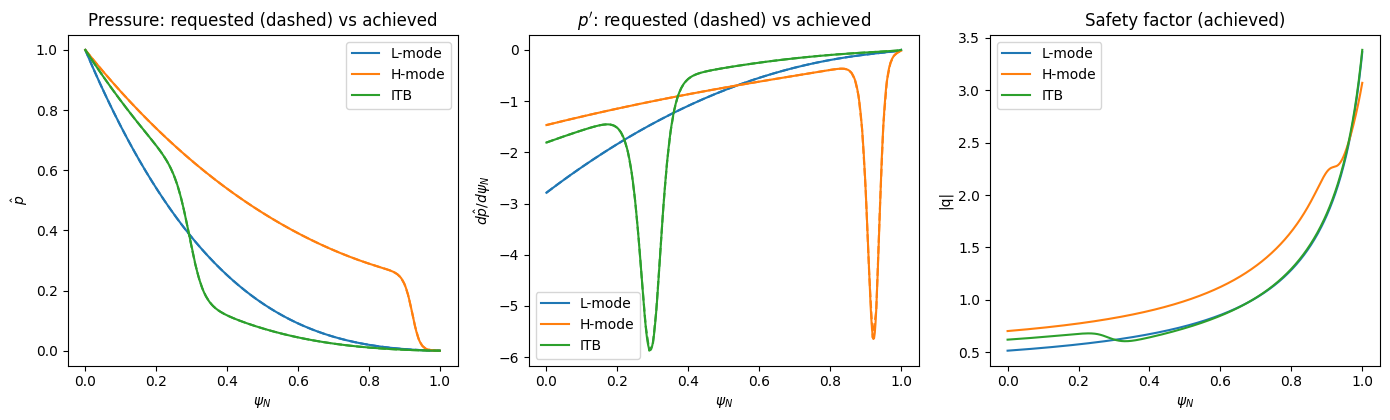

H-mode: steepest achieved p' at psi_N = 0.922 (requested barrier centre 0.93)
ITB: steepest achieved p' at psi_N = 0.293 (requested barrier centre 0.3)


In [ ]:
if HAVE_CHEASE:
    fig, axes = plt.subplots(1, 3, figsize=(14, 4.3))
    for (name, r), color in zip(regime_results.items(), ("C0", "C1", "C2")):
        req, got = r.source_profiles, r.achieved_profiles
        if not got:
            print(f"{name}: no achieved profiles ({r.status})"); continue
        axes[0].plot(req["psi_n"], req["pressure_norm"], "--", color=color)
        axes[0].plot(got["psi_n"], got["pressure_norm"], "-", color=color, label=name)
        axes[1].plot(req["psi_n"], req["pprime_norm"], "--", color=color)
        axes[1].plot(got["psi_n"], got["pprime_norm"], "-", color=color, label=name)
        axes[2].plot(got["psi_n"], got["q"], "-", color=color, label=name)
    axes[0].set(xlabel=r"$\psi_N$", ylabel=r"$\hat p$", title="Pressure: requested (dashed) vs achieved")
    axes[1].set(xlabel=r"$\psi_N$", ylabel=r"$d\hat p/d\psi_N$", title=r"$p'$: requested (dashed) vs achieved")
    axes[2].set(xlabel=r"$\psi_N$", ylabel="|q|", title="Safety factor (achieved)")
    for ax in axes:
        ax.legend()
    fig.tight_layout(); plt.show()
    for name, r in regime_results.items():
        got = r.achieved_profiles
        if got:
            barrier = {"H-mode": 0.93, "ITB": 0.30}.get(name)
            if barrier is not None:
                near = np.abs(got["psi_n"] - barrier) < 0.15
                where = got["psi_n"][near][np.argmin(got["pprime_norm"][near])]
                print(f"{name}: steepest achieved p' at psi_N = {where:.3f} (requested barrier centre {barrier})")

The achieved normalized pressure follows the requested barrier profile to
within about $10^{-3}$. The steepest achieved $p'$ sits where the requested
$p'$ is steepest, to within the output mesh. For the presets that is slightly
inside the channels' layer centre (0.92 against 0.93, 0.29 against 0.30),
because $p = e\,n\,T$ multiplies two stepped channels. The amplitudes are still outputs:
$\beta_t$ and $l_i$ differ between the cases at the same $I_p$ because the
*shape* of the source differs, just as in Section 4.

### 5.2 How steep a pedestal survives the solve

The mesh sets how narrow a barrier CHEASE resolves. A narrower pedestal keeps
the pressure *shape* but loses the $p'$ peak: the CHEASE input is sampled on
257 points and CHEASE resamples it onto its own mesh. The table below narrows
the H-mode pedestal and reports the miss in the peak normalized $p'$. The
states are printed as returned, so a solve that fails to converge stays
visible. At a full width of 0.01, the pressure shape still
misses by only about 1 %, but a quarter of the $p'$ peak is lost to the mesh.
The pressure-shape residual cannot see that loss. With barrier steps, the
steepest $p'$ is therefore checked on its own: `residuals["pprime_peak"]`
against `pprime_peak_tolerance` (0.1 relative), and its location against
`pprime_peak_location_tolerance`. The narrowest case is then returned as
`constraint_not_reached`, which is the honest outcome.

In [ ]:
if HAVE_CHEASE:
    print(f"{'width':>6s} {'centre':>6s} {'status':24s} {'p shape miss':>12s} {'peak p* requested':>18s} {'achieved':>9s}")
    for width, centre in ((0.05, 0.93), (0.02, 0.97), (0.01, 0.98)):
        spec = dataclasses.replace(vest, pressure_fraction=0.3,
                                   pressure_profile=analytic_hmode_state(pedestal_width=width, pedestal_position=centre))
        r = synthesize_equilibrium_from_0d(spec, config=CHEASEConfig(workdir=WORK / f"width_{width}"))
        _, dp_req = requested_pressure_shape(spec, np.linspace(0, 1, 20001))
        got = r.achieved_profiles
        achieved_peak = got["pprime_norm"].min() if got else float("nan")
        print(f"{width:6.2f} {centre:6.2f} {r.status:24s} {r.residuals.get('pressure_shape', float('nan')):12.2e} "
              f"{dp_req.min():18.2f} {achieved_peak:9.2f}" + (f"  ({r.reason})" if r.reason else ""))

 width centre status                   p shape miss  peak p* requested  achieved


  0.05   0.93 success                      3.75e-04              -5.68     -5.64


  0.02   0.97 success                      2.89e-03             -14.33    -13.41


  0.01   0.98 constraint_not_reached       1.07e-02             -28.65    -21.69  (the barrier's steepest p' is not reproduced: peak off by -0.243 (relative), at psi_N offset -3.44e-05; the solve does not resolve the barrier)


### 5.3 An edge-current pedestal in $FF'$

`current_profile` is a profile $g(\psi_N)$ that plays the role of $F^2/2$
above its edge value, and the $FF'$ shape is $-dg/d\psi_N$. A pedestal step in
$g$ is therefore an edge-current bump. It has the $\mathrm{sech}^2$ shape of
the tanh step's derivative, centred on the step and as wide as it.

The bump is a prescribed edge current (a stand-in for a bootstrap current),
not a computed one. Here it sits on the H-mode pedestal.

With the same $I_p$ and shape of $p'$, moving current into the edge bump
raises $q$ in the core. It also reverses the shear locally across the
pedestal, where $q$ dips. That reversal follows from the prescription and is
not a prediction.

status: success
  ip                      99999
  q0                      1.2428
  q95                     2.5102
  bt0                     0.099999
  major_radius            0.4
  minor_radius            0.235
  elongation              1.6999
  geometric_center_z      0
  beta_t                  0.071958
  beta_n                  1.691
  li_virial               0.29382
  shafranov_shift         0.03421
  magnetic_axis_r         0.43421
  magnetic_axis_z        -2.6883e-11
  volume                  0.69211
  beta_p                  0.18871
  triangularity_upper     0.34922
  triangularity_lower     0.34922
  residuals: {'plasma_current': -0.0, 'toroidal_field': -0.0, 'elongation': -0.0001, 'minor_radius': -0.0, 'major_radius': 0.0, 'triangularity_upper': -0.0008, 'triangularity_lower': -0.0008, 'vertical_position': 0.0, 'pressure_shape': 0.0004, 'pprime_peak': -0.0071, 'pprime_peak_location': -0.0006}


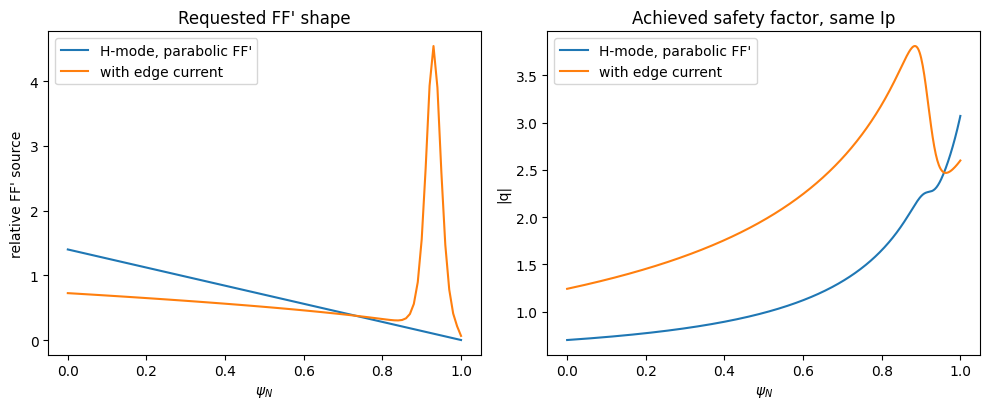

In [ ]:
if HAVE_CHEASE:
    edge_current = compose_analytic_profile("g", unit="", axis_value=1.0, separatrix_value=0.01,
                                            pedestal_top_value=0.3, pedestal_position=0.93, pedestal_width=0.05)
    with_current = synthesize_equilibrium_from_0d(
        dataclasses.replace(regime_specs["H-mode"], current_profile=edge_current),
        config=CHEASEConfig(workdir=WORK / "edge_current"))
    show(with_current)
    base = regime_results["H-mode"]
    fig, (f_ax, q_ax) = plt.subplots(1, 2, figsize=(10, 4.2))
    f_ax.plot(base.source_profiles["psi_n"], base.source_profiles["ffprime_shape"], label="H-mode, parabolic FF'")
    f_ax.plot(with_current.source_profiles["psi_n"], with_current.source_profiles["ffprime_shape"], label="with edge current")
    f_ax.set(xlabel=r"$\psi_N$", ylabel="relative FF' source", title="Requested FF' shape")
    for r, label in ((base, "H-mode, parabolic FF'"), (with_current, "with edge current")):
        if r.achieved_profiles:
            q_ax.plot(r.achieved_profiles["psi_n"], r.achieved_profiles["q"], label=label)
    q_ax.set(xlabel=r"$\psi_N$", ylabel="|q|", title="Achieved safety factor, same Ip")
    f_ax.legend(); q_ax.legend(); fig.tight_layout(); plt.show()

## 6. What is refused, and how

A quantity CHEASE cannot impose is refused as `unsupported_target`, not
silently treated as an output or reached by editing the result. Invalid
geometry and invalid source models are also refused before CHEASE runs.

In [ ]:
for label, result in (
    ("beta_p target", synthesize_equilibrium_from_0d(vest, target="beta_p")),
    ("minor radius > R0", synthesize_equilibrium_from_0d(dataclasses.replace(vest, minor_radius=0.5))),
    ("pure-pressure source", synthesize_equilibrium_from_0d(dataclasses.replace(vest, pressure_fraction=1.0))),
    ("profile and kernel", synthesize_equilibrium_from_0d(dataclasses.replace(vest, pressure_profile=hmode_p, pressure_beta=3.0))),
):
    print(f"{label:22s} -> {result.status}: {result.reason}")

beta_p target          -> unsupported_target: CHEASE can normalize to ['plasma_current', 'q95'] only; 'beta_p' would be an output, not a control
minor radius > R0      -> invalid_geometry: requires major_radius > minor_radius > 0
pure-pressure source   -> invalid_source_model: pressure_fraction must lie in [0, 1): FF' may not vanish identically
profile and kernel     -> invalid_source_model: both a generalized-parabolic pressure shape (pressure_alpha, pressure_beta) and a pressure_profile were given; the profile replaces the kernel, so give one or the other
